In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from cns.utils.assemblies import hg19
from cns.analyze.labels import *
from cns.analyze.genome import *
from cns.analyze.heatmap import *
from cns.process.binning import *
from cns.process.breakpoints import *

# auto reload modules
%load_ext autoreload
%autoreload 2

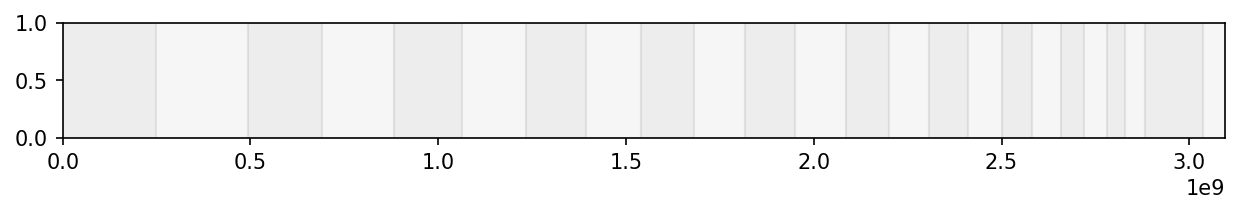

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(10, 1), dpi=150)
plot_chr_bg(ax, hg19)

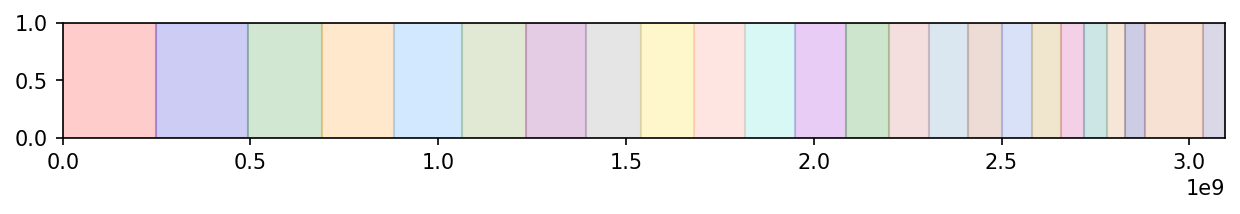

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 1), dpi=150)
plot_chr_bg(ax, hg19, colored=True)

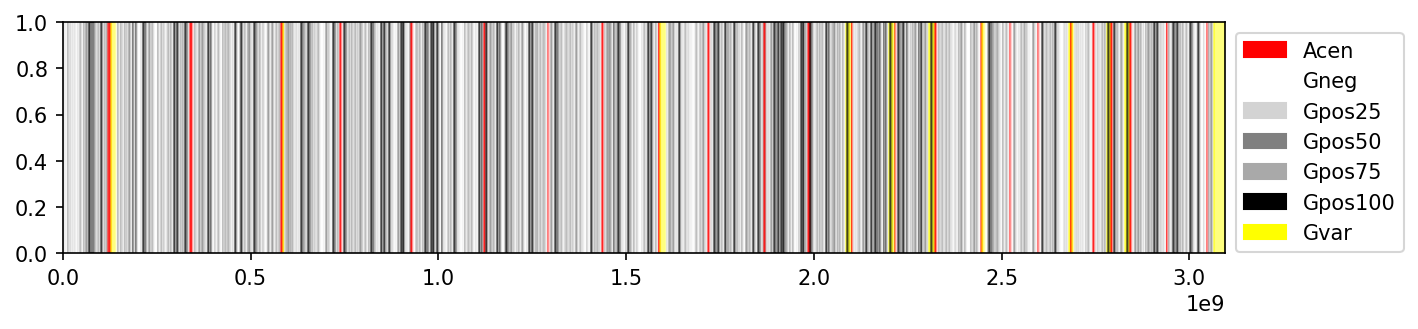

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_cytobands(ax, hg19, alpha=.5)
add_cytoband_legend(ax)

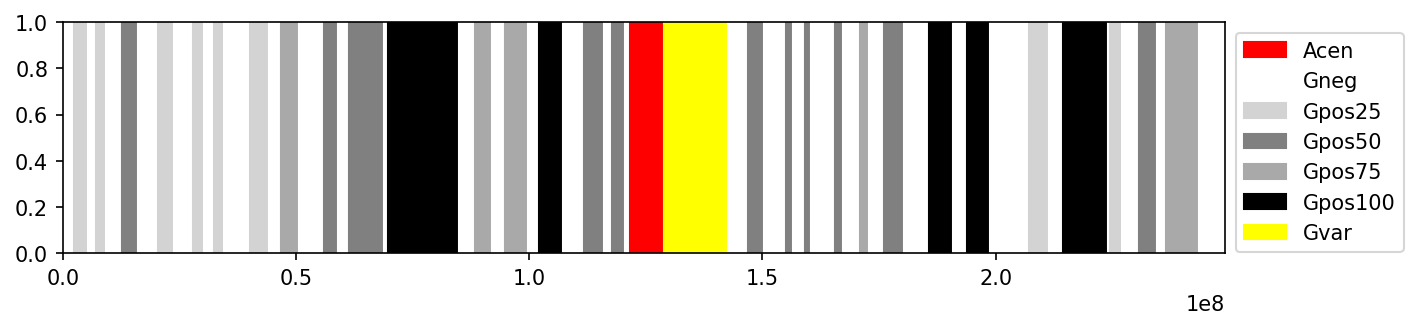

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_cytobands(ax, hg19, alpha=1, sel_chrom="chr1")
add_cytoband_legend(ax)

In [6]:
hg19.cytobands[:5]

(('chr1', 0, 2300000, 'p36.33', 'gneg'),
 ('chr1', 2300000, 5400000, 'p36.32', 'gpos25'),
 ('chr1', 5400000, 7200000, 'p36.31', 'gneg'),
 ('chr1', 7200000, 9200000, 'p36.23', 'gpos25'),
 ('chr1', 9200000, 12700000, 'p36.22', 'gneg'))

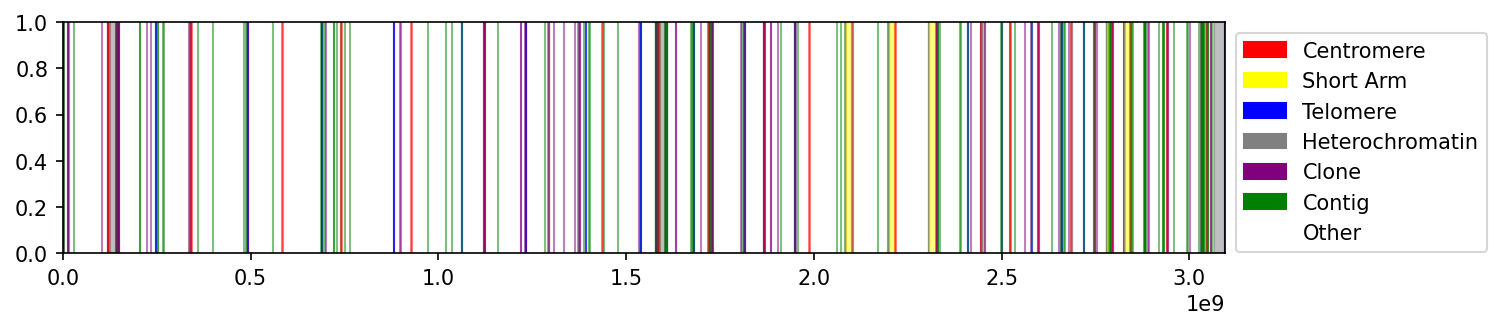

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_gaps(ax, hg19, alpha=.5)
add_gap_legend(ax)

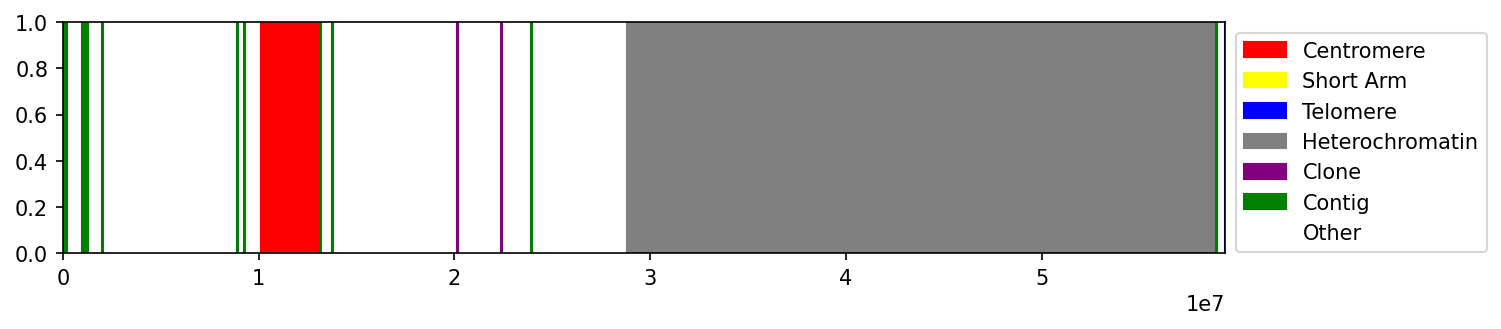

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_gaps(ax, hg19, alpha=1, sel_chrom="chrY")
add_gap_legend(ax)

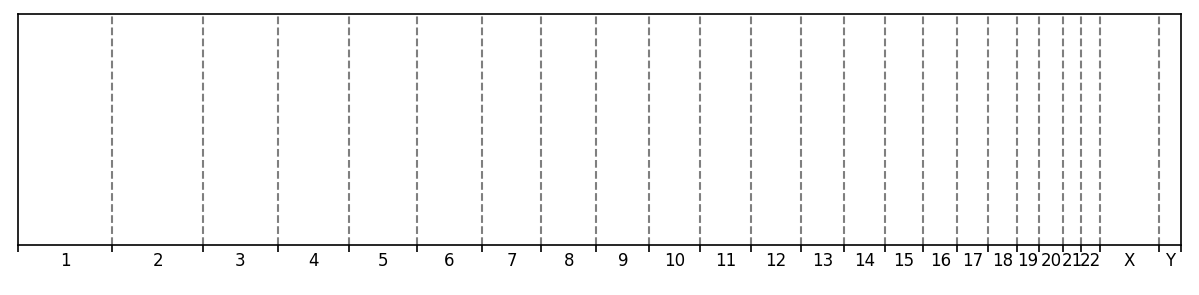

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_x_ticks(ax, hg19)
plot_x_lines(ax, hg19)
no_y_ticks(ax)

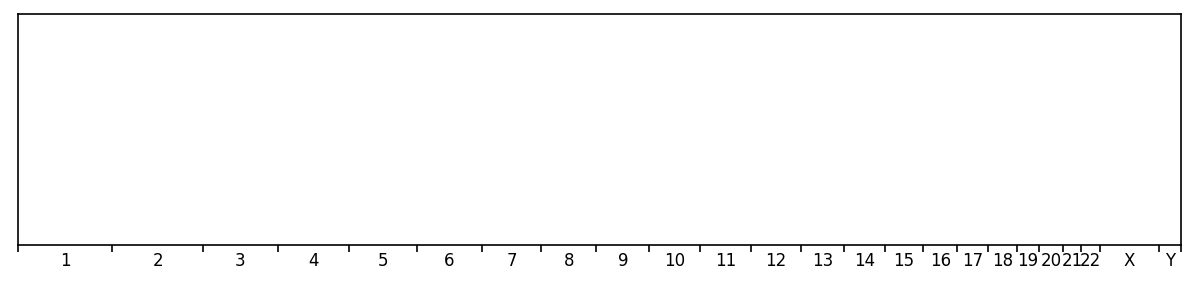

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_x_ticks(ax, hg19)
# plot_x_lines(ax, hg19) 
no_y_ticks(ax)

# Plots

In [12]:
pcawg_cns_df = pd.read_csv("../../out/PCAWG_cns_imp.tsv", sep="\t")
sample_ids = pcawg_cns_df["sample_id"].unique()
pcawg_cns_10_df = pcawg_cns_df[pcawg_cns_df["sample_id"].isin(sample_ids[:10])].copy()
pcawg_10_bin_df = bin_by_breaks(pcawg_cns_10_df, get_breakpoints(str(int(1e5)), hg19))
pcawg_10_groups_df = mean_bins(add_derived(pcawg_10_bin_df, hg19), hg19)
max_cn = 10

Binning chr (231/231)


In [13]:
def line_plot2(ax, grouped, column, color="red", label=None, alpha=1, line_width=1, sel_chrom=None):
    chroms = grouped["chrom"].unique() if sel_chrom is None else [sel_chrom]
    for chr in chroms:
        df = grouped.query(f"chrom == '{chr}'").copy()
        df["is_consecutive"] = df["start"] - df["end"].shift(1) != 0
        for _, group_df in df.groupby(df["is_consecutive"].cumsum()):
            ax.plot(
                group_df["cum_mid" if sel_chrom is None else "mid"],
                group_df[column],
                c=color,
                linewidth=line_width,
                label=label,
                alpha=alpha,
            )
            label = None  # only use label for the first chromosome
    return ax


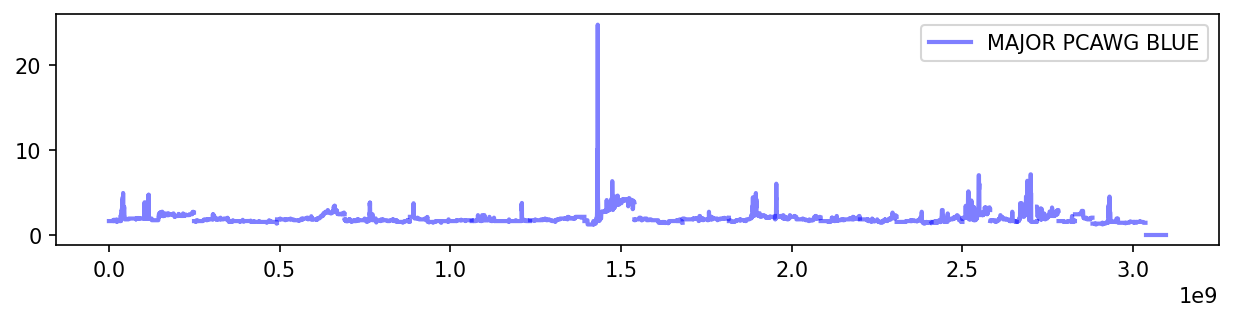

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
line_plot(ax, pcawg_10_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

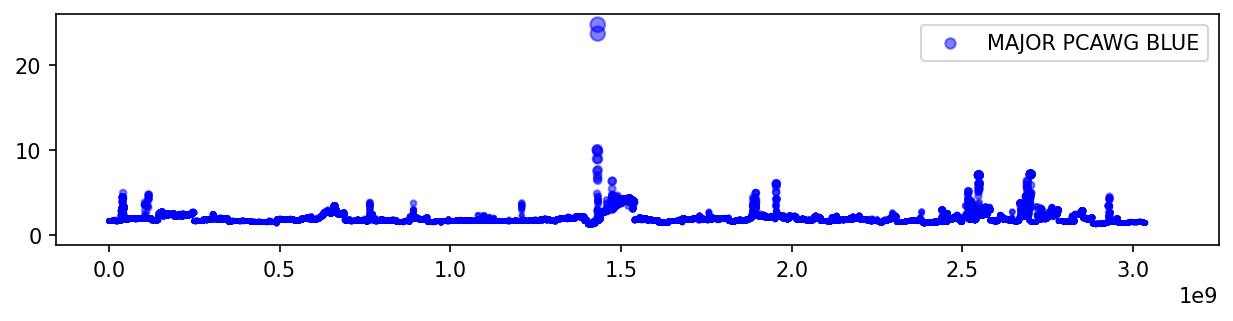

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
scatter_plot(ax, pcawg_10_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

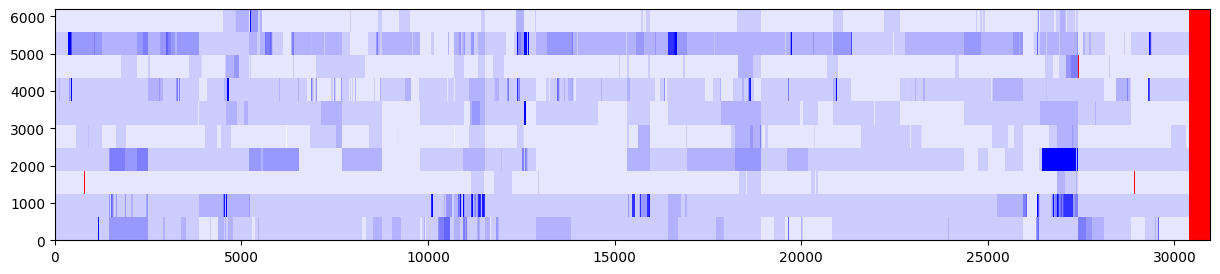

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(24, 3))
plot_CN_heatmap(ax, pcawg_10_bin_df, "major_cn");